# State-Level Predictors of Mask Improvement

Visualises `outputs/state_predictors.csv` — every candidate explanation for why the
rice crop mask helps in some states and not others.

Predictors are grouped by **how much a correlation can be trusted**:

| Group | Meaning |
|---|---|
| **CENSUS** | built only from government statistics — independent of the crop map |
| **MAP** | derived from the same Jordi map whose mask produces the outcome — **circular** |
| **MECHANICAL** | appears in the algebra of the outcome (`rel = Δr / (1 − baseline_r)`) |

A MAP predictor correlating with Δr is close to the map predicting its own effect, so
those panels are drawn in red and should not be read as evidence about agriculture.


In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'figure.titlesize': 20,
})

ROOT = '../..'
OUT  = f'{ROOT}/outputs'
M = pd.read_csv(f'{OUT}/state_predictors.csv')

LBL = {'punjab':'Punjab','mp':'Madhya Pradesh','up':'Uttar Pradesh','wb':'West Bengal',
 'telangana':'Telangana','maharashtra':'Maharashtra','karnataka':'Karnataka',
 'andhra_pradesh':'Andhra Pradesh','tamil_nadu':'Tamil Nadu','odisha':'Odisha',
 'jharkhand':'Jharkhand','assam':'Assam','manipur':'Manipur','haryana':'Haryana',
 'tripura':'Tripura','bihar':'Bihar','chhattisgarh':'Chhattisgarh','gujarat':'Gujarat',
 'himachal_pradesh':'Himachal Pradesh','kerala':'Kerala','meghalaya':'Meghalaya',
 'mizoram':'Mizoram','nagaland':'Nagaland','rajasthan':'Rajasthan',
 'uttarakhand':'Uttarakhand','goa':'Goa','puducherry':'Puducherry',
 'chandigarh':'Chandigarh','andaman_nicobar':'Andaman & Nicobar',
 'dadra_nagar_haveli':'Dadra & Nagar Haveli'}
M['label'] = M['region_key'].map(LBL).fillna(M['region_key'])

# predictor -> (display name, group)
GROUP_COLOR = {'CENSUS': '#2c7fb8', 'MAP': '#c0504d', 'MECHANICAL': '#7f7f7f'}
PRED = [
    ('rice_share_5crop',     'Rice share\n(rice / 5-crop area)',      'CENSUS'),
    ('rice_share_allcrop',   'Rice share\n(rice / all 30 crops)',     'CENSUS'),
    ('rice_over_land',       'Rice share\n(rice / total land area)',  'CENSUS'),
    ('rice_share_5crop_cv',  'Rice share CV\n(across districts)',     'CENSUS'),
    ('census_entropy_mean',  'Census crop entropy\nmean',             'CENSUS'),
    ('census_entropy_cv',    'Census crop entropy\nCV',               'CENSUS'),
    ('map_entropy_mean',     'MAP crop entropy\nmean',                'MAP'),
    ('map_entropy_cv',       'MAP crop entropy\nCV',                  'MAP'),
    ('retention',            'Mask retention\n(fraction of px kept)', 'MAP'),
    ('baseline_r',           'Baseline r\n(raw GCVI vs yield)',       'MECHANICAL'),
]
print(f"{len(M)} states, {M['delta'].notna().sum()} with a crop-mask Δr")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


30 states, 27 with a crop-mask Δr


## 1. Summary — every predictor, ranked by strength

In [2]:
rows = []
for c, name, grp in PRED:
    for ycol, yname in [('delta', 'Δr'), ('rel', 'rel. improvement')]:
        v = M[[c, ycol]].dropna()
        if len(v) < 5 or v[c].std() == 0:
            continue
        r, p   = stats.pearsonr(v[c], v[ycol])
        rho, _ = stats.spearmanr(v[c], v[ycol])
        rows.append({'predictor': name.replace('\n', ' '), 'group': grp,
                     'outcome': yname, 'r': r, 'p': p, 'spearman': rho, 'n': len(v)})
S = pd.DataFrame(rows)

print("ranked by |r| against relative improvement\n")
t = (S[S.outcome == 'rel. improvement'].reindex(
        S[S.outcome == 'rel. improvement']['r'].abs().sort_values(ascending=False).index))
print(f"{'predictor':<34}{'group':<12}{'r':>7}{'p':>8}{'rho':>7}{'n':>5}")
print('-' * 74)
for _, x in t.iterrows():
    print(f"{x['predictor']:<34}{x['group']:<12}{x['r']:>7.2f}{x['p']:>8.3f}"
          f"{'*' if x['p']<0.05 else ' '}{x['spearman']:>6.2f}{x['n']:>5}")
S.to_csv(f'{OUT}/predictor_summary.csv', index=False)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## 2. Effect-size chart

Horizontal bars make the grouping obvious: the significant results are almost all
MAP-derived. Bonferroni threshold shown for the 10 predictors tested.

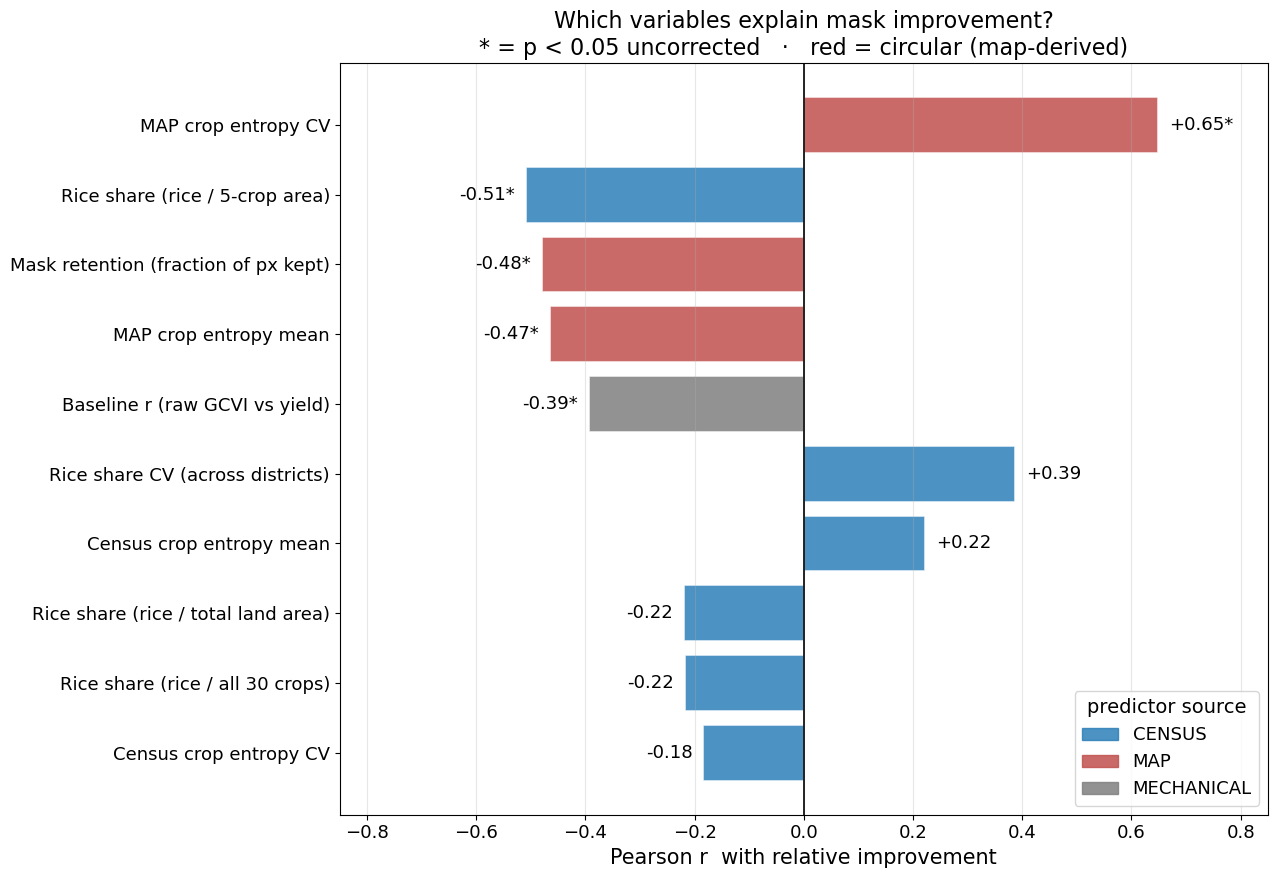

In [3]:
t = S[S.outcome == 'rel. improvement'].copy()
t = t.reindex(t['r'].abs().sort_values().index)

fig, ax = plt.subplots(figsize=(13, 9))
cols = [GROUP_COLOR[g] for g in t['group']]
bars = ax.barh(t['predictor'], t['r'], color=cols, alpha=0.85,
               edgecolor='white', linewidth=1.2)
for b, (_, x) in zip(bars, t.iterrows()):
    off = 0.02 if x['r'] >= 0 else -0.02
    ax.text(x['r'] + off, b.get_y() + b.get_height()/2,
            f"{x['r']:+.2f}{'*' if x['p']<0.05 else ''}",
            va='center', ha='left' if x['r'] >= 0 else 'right', fontsize=13)
ax.axvline(0, color='black', lw=1.2)
ax.set_xlabel('Pearson r  with relative improvement')
ax.set_xlim(-0.85, 0.85)
ax.grid(axis='x', alpha=0.3)
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.85) for c in GROUP_COLOR.values()]
ax.legend(handles, GROUP_COLOR.keys(), title='predictor source', loc='lower right')
ax.set_title('Which variables explain mask improvement?\n'
             '* = p < 0.05 uncorrected   ·   red = circular (map-derived)')
plt.tight_layout()
plt.savefig(f'{OUT}/predictor_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rice-share predictors

Three denominators for the same numerator. The sign is consistently negative — the mask
helps most where rice is a *smaller* share — but only the 5-crop denominator reaches
significance, which is worth treating with caution.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


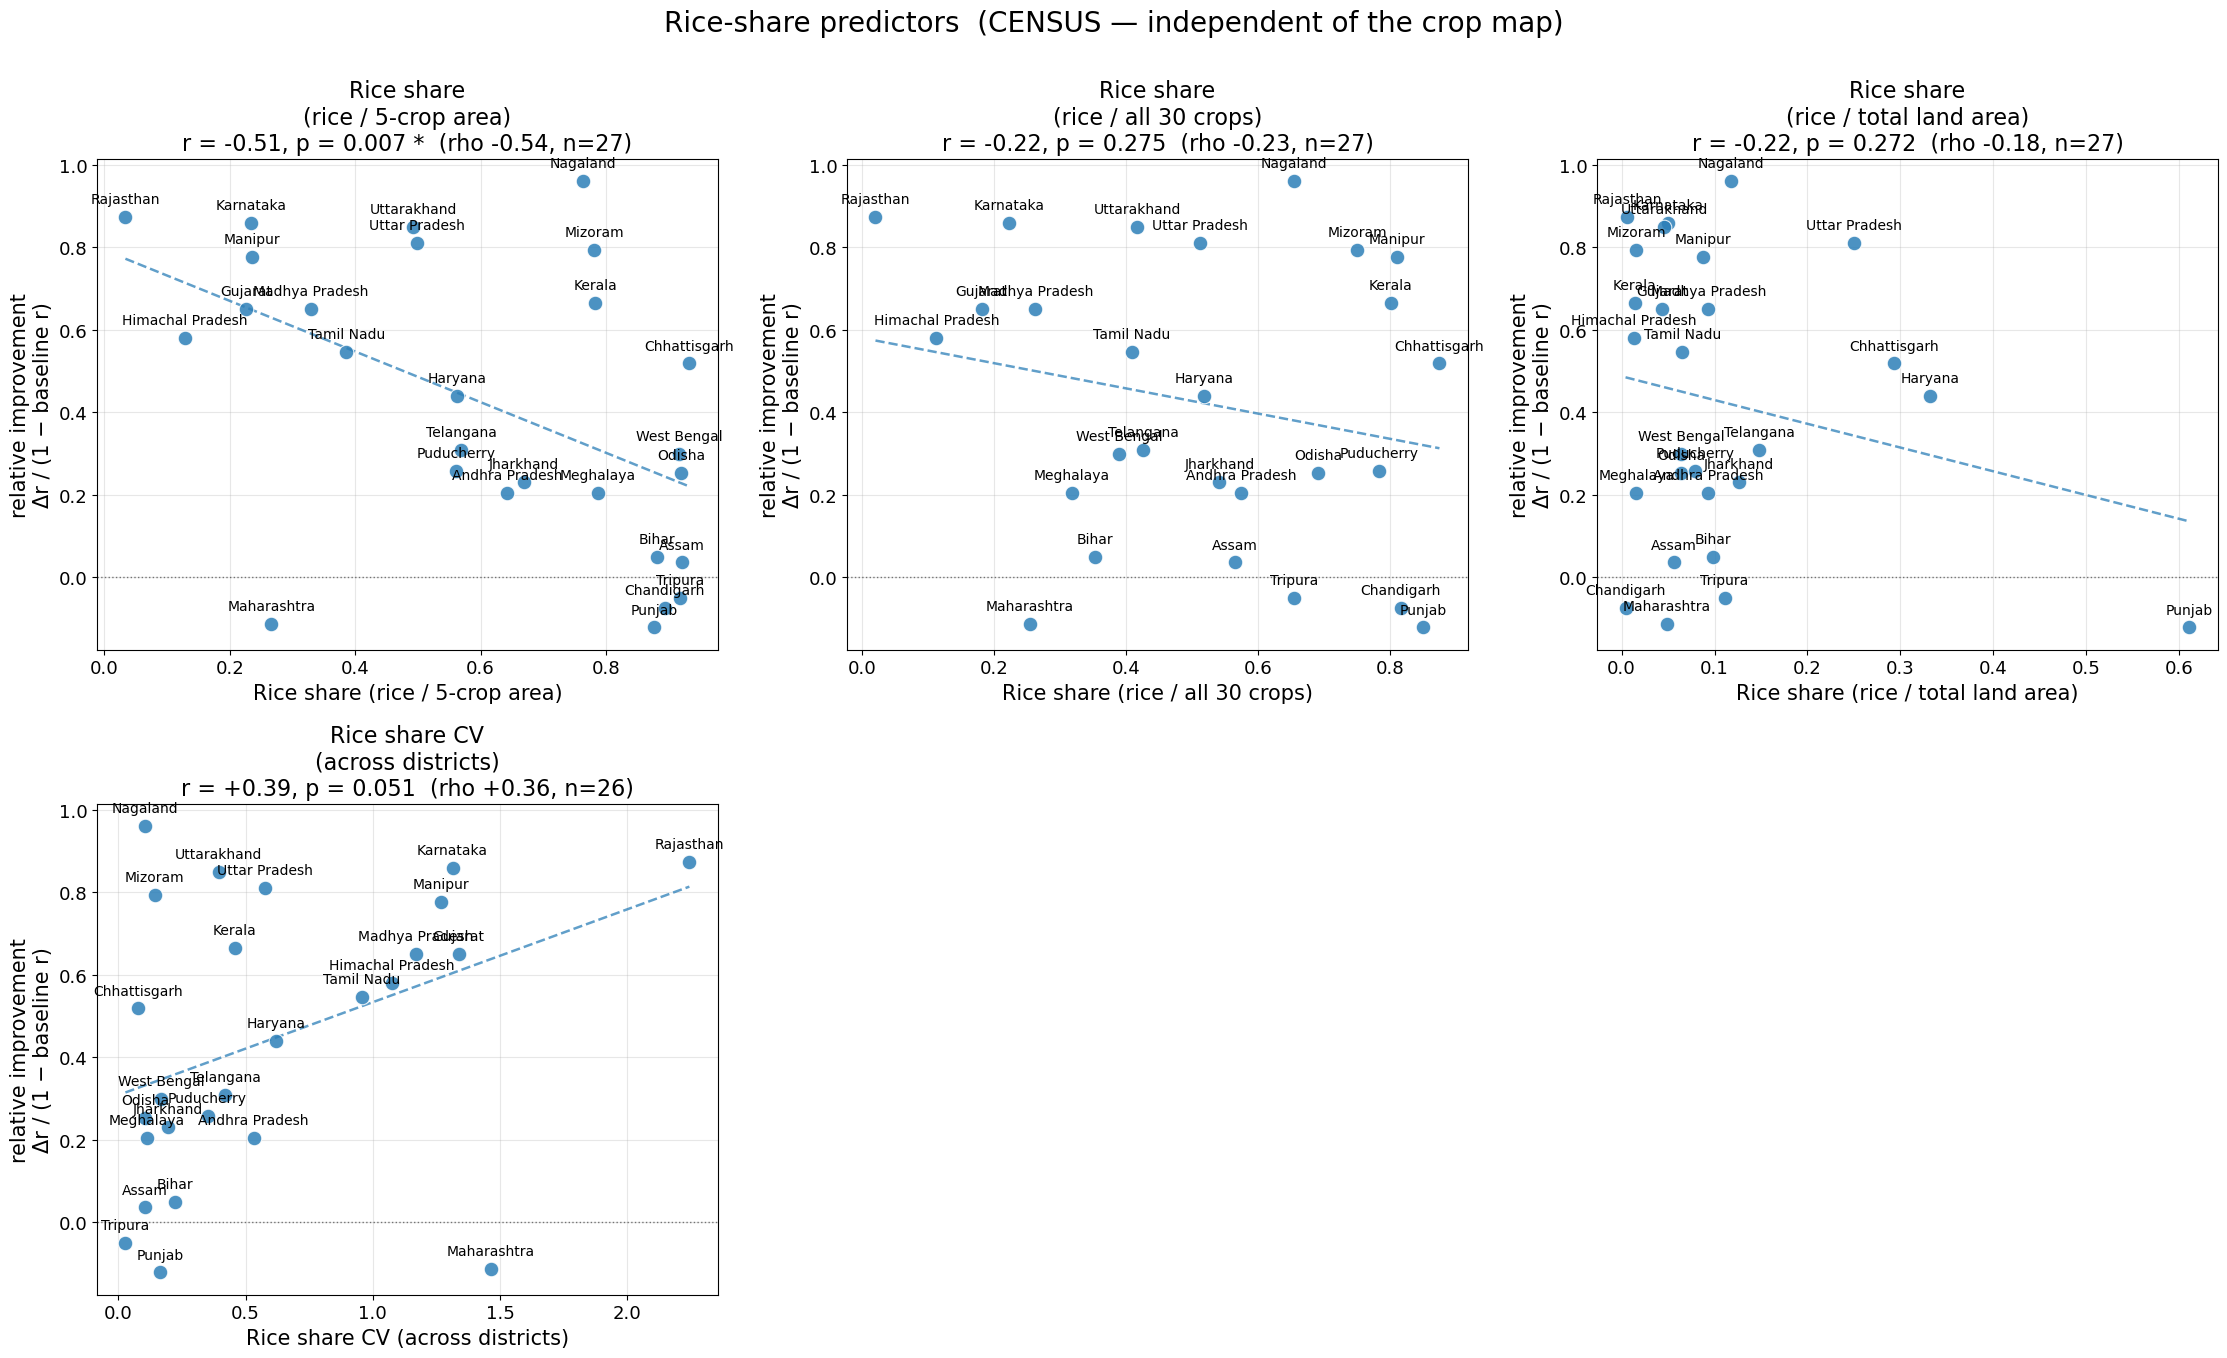

In [4]:
def panel_grid(preds, ycol, ylab, fname, suptitle, ncols=3):
    n = len(preds)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 6.8 * nrows),
                             squeeze=False)
    for ax, (c, name, grp) in zip(axes.flat, preds):
        v = M[[c, ycol, 'label']].dropna()
        col = GROUP_COLOR[grp]
        ax.scatter(v[c], v[ycol], s=110, color=col, edgecolors='white',
                   linewidths=0.8, alpha=0.85, zorder=3)
        for _, r_ in v.iterrows():
            ax.annotate(r_['label'], (r_[c], r_[ycol]), fontsize=10,
                        textcoords='offset points', xytext=(0, 10), ha='center')
        if len(v) > 2 and v[c].std() > 0:
            b, a_ = np.polyfit(v[c], v[ycol], 1)
            xs = np.linspace(v[c].min(), v[c].max(), 50)
            ax.plot(xs, b * xs + a_, color=col, lw=1.8, ls='--', alpha=0.75, zorder=2)
            r, p   = stats.pearsonr(v[c], v[ycol])
            rho, _ = stats.spearmanr(v[c], v[ycol])
            ax.set_title(f'{name}\nr = {r:+.2f}, p = {p:.3f}'
                         f'{" *" if p < 0.05 else ""}  (rho {rho:+.2f}, n={len(v)})')
        ax.axhline(0, color='black', lw=1.0, ls=':', alpha=0.5)
        ax.set_xlabel(name.replace('\n', ' '))
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.3)
    for ax in list(axes.flat)[n:]:
        ax.axis('off')
    fig.suptitle(suptitle, y=1.0)
    plt.tight_layout()
    plt.savefig(f'{OUT}/{fname}', dpi=150, bbox_inches='tight')
    plt.show()

panel_grid([p for p in PRED if p[0].startswith('rice')],
           'rel', 'relative improvement\nΔr / (1 − baseline r)',
           'predictors_rice_share.png',
           'Rice-share predictors  (CENSUS — independent of the crop map)')

## 4. Crop entropy — census vs map

Same statistic (Shannon entropy of the cropping mix, mean and CV across districts)
computed two ways. **The census versions are null; the map versions are the strongest
results in the whole table.** Since the two disagree entirely (district-level
r = −0.009), that gap is the clearest evidence that the map-derived signal is an
artifact of the map rather than a property of agriculture.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


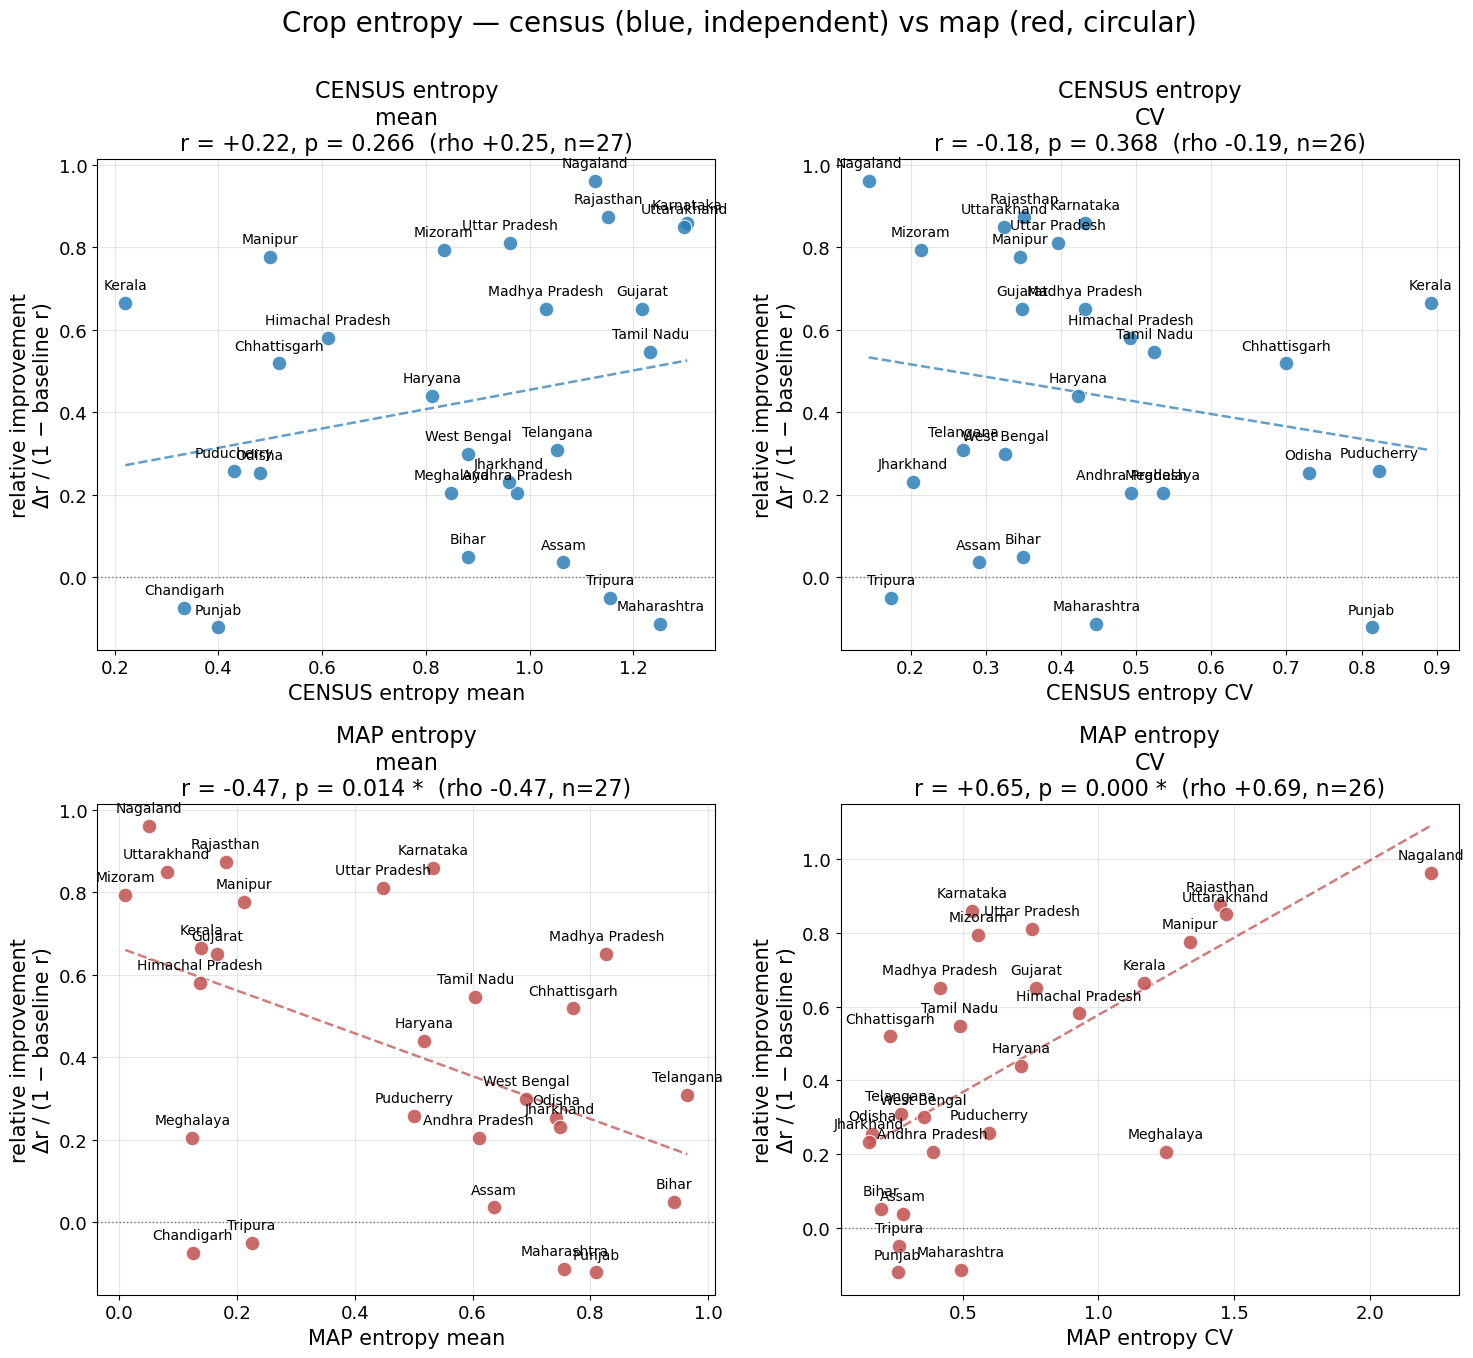

In [5]:
panel_grid([('census_entropy_mean', 'CENSUS entropy\nmean',  'CENSUS'),
            ('census_entropy_cv',   'CENSUS entropy\nCV',    'CENSUS'),
            ('map_entropy_mean',    'MAP entropy\nmean',     'MAP'),
            ('map_entropy_cv',      'MAP entropy\nCV',       'MAP')],
           'rel', 'relative improvement\nΔr / (1 − baseline r)',
           'predictors_entropy.png',
           'Crop entropy — census (blue, independent) vs map (red, circular)',
           ncols=2)

## 5. Census vs map entropy, head to head

If the two measured the same thing they would line up on the diagonal.

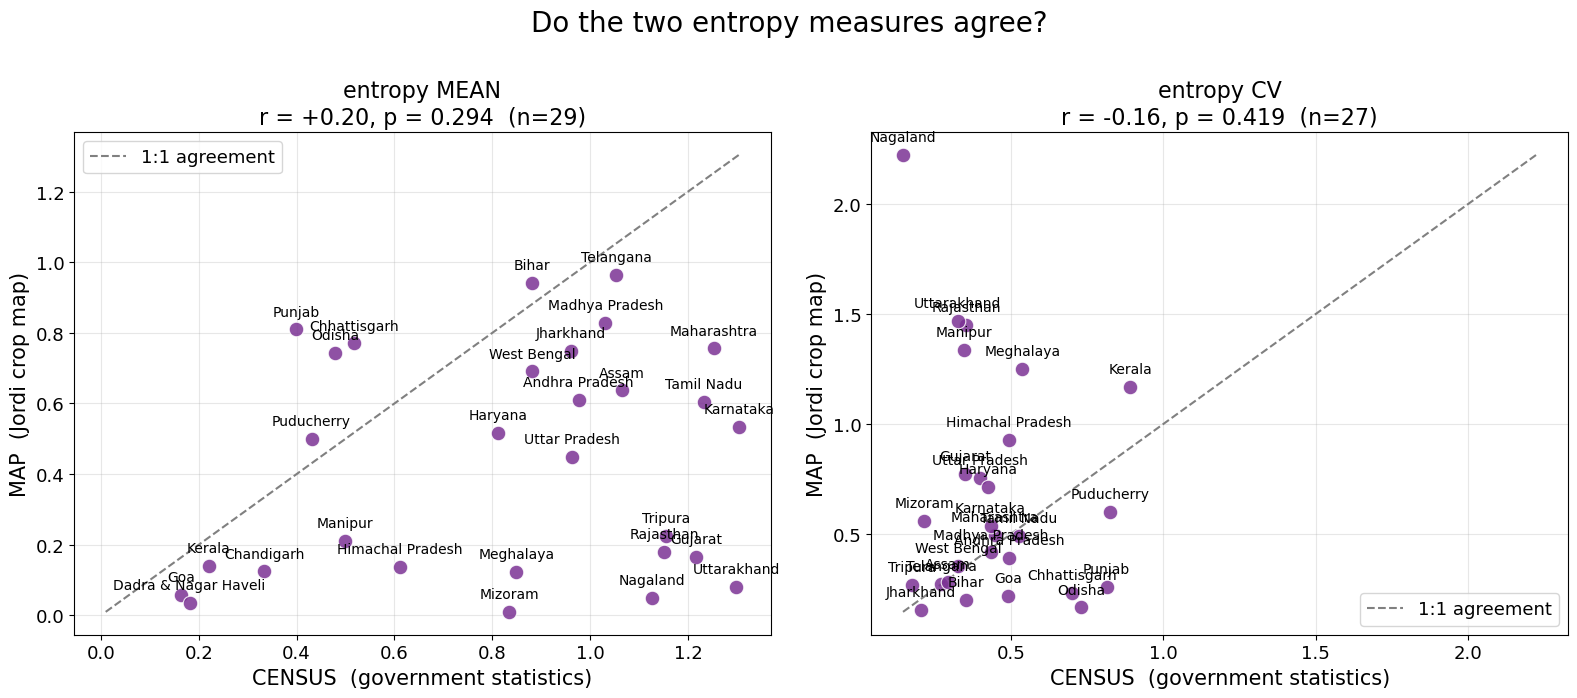

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (a, b, lab) in zip(axes, [
        ('census_entropy_mean', 'map_entropy_mean', 'entropy MEAN'),
        ('census_entropy_cv',   'map_entropy_cv',   'entropy CV')]):
    v = M[[a, b, 'label']].dropna()
    ax.scatter(v[a], v[b], s=110, color='#7b3294', edgecolors='white',
               linewidths=0.8, alpha=0.85, zorder=3)
    for _, r_ in v.iterrows():
        ax.annotate(r_['label'], (r_[a], r_[b]), fontsize=10,
                    textcoords='offset points', xytext=(0, 10), ha='center')
    lo = min(v[a].min(), v[b].min()); hi = max(v[a].max(), v[b].max())
    ax.plot([lo, hi], [lo, hi], ls='--', c='grey', lw=1.5, label='1:1 agreement')
    r, p = stats.pearsonr(v[a], v[b])
    ax.set_title(f'{lab}\nr = {r:+.2f}, p = {p:.3f}  (n={len(v)})')
    ax.set_xlabel('CENSUS  (government statistics)')
    ax.set_ylabel('MAP  (Jordi crop map)')
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('Do the two entropy measures agree?', y=1.0)
plt.tight_layout()
plt.savefig(f'{OUT}/predictors_entropy_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation matrix

How the predictors relate to each other. Blocks of high correlation mean the variables
are not independent explanations.

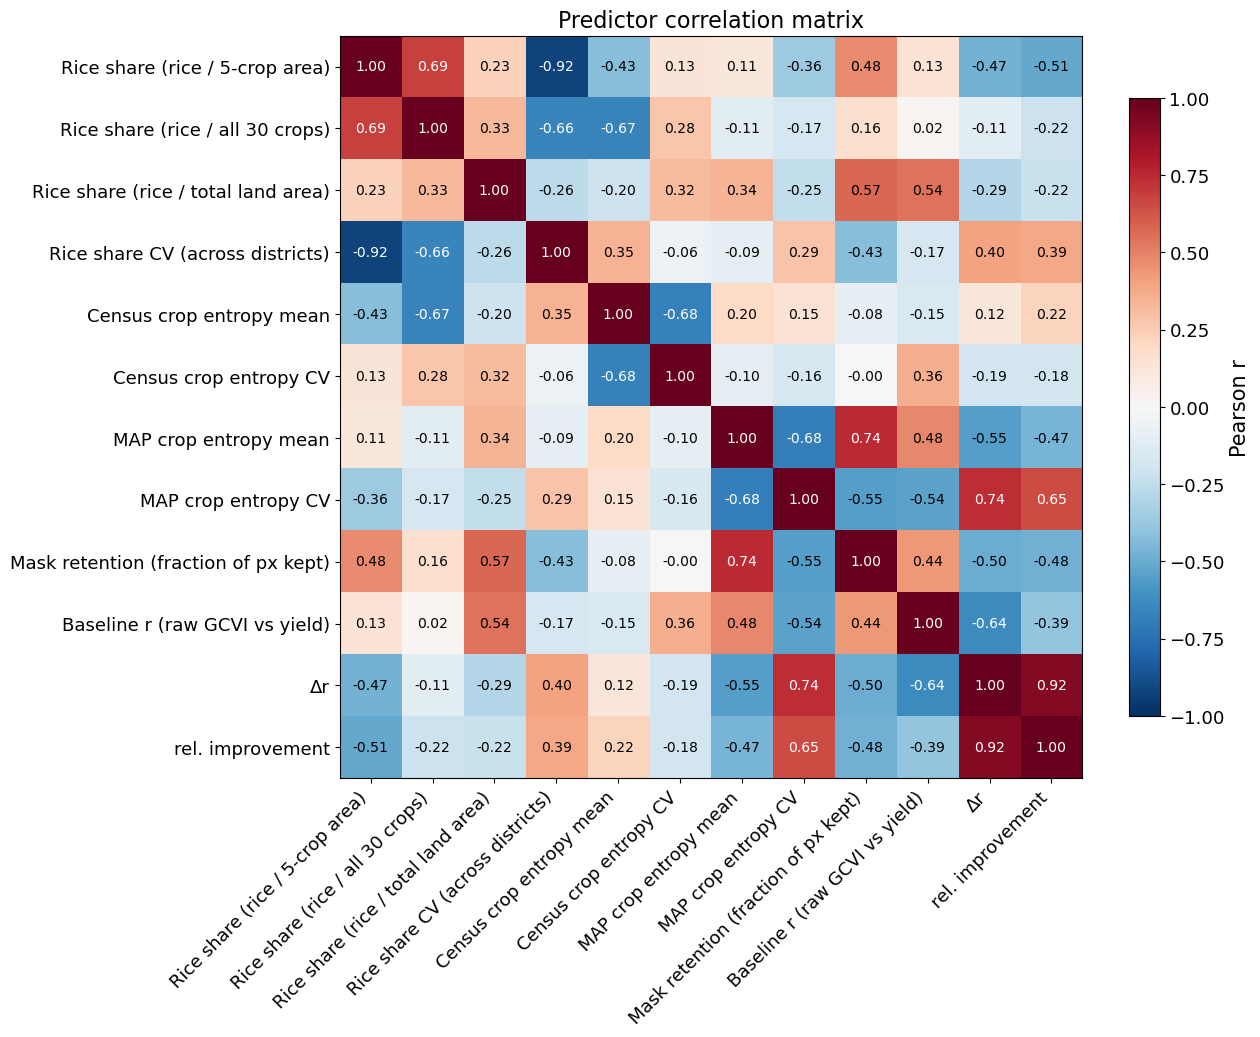

In [7]:
cols = [c for c, _, _ in PRED] + ['delta', 'rel']
names = [n.replace('\n', ' ') for _, n, _ in PRED] + ['Δr', 'rel. improvement']
Cm = M[cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(Cm.values, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = Cm.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if abs(v) > 0.6 else 'black')
ax.set_xticks(range(len(cols))); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_yticks(range(len(cols))); ax.set_yticklabels(names)
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.75)
ax.set_title('Predictor correlation matrix')
plt.tight_layout()
plt.savefig(f'{OUT}/predictors_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Caveats

- **n = 27–30 states.** Minimum detectable |r| at 80% power is ≈ **0.52** — anything
  weaker is invisible by construction.
- **10 predictors tested.** P(≥1 false positive at α = 0.05) ≈ **40%**. Under Bonferroni
  (p < 0.005) only `map_entropy_cv` survives — and that one is circular.
- **Rice share is fragile to the denominator**: −0.51 with the 5-crop denominator,
  −0.22 with all crops, −0.22 with total land area. Same numerator, same source.
- `baseline_r` is **mechanical** — it sits in the denominator of `rel`, so it correlates
  by construction. Treat it as a covariate to control for, not an explanation.
